In [1]:
!pip install pyngrok


In [2]:
!pip install timm==0.6.12
!pip install scikit-learn matplotlib seaborn pillow gradio opencv-python-headless

import os, time, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm


In [3]:
train_dir = r"E:\Brain Tumor Dataset\Testing"
test_dir  = r"E:\Brain Tumor Dataset\Training"

classes = ["glioma", "meningioma", "pituitary", "notumor"]
class_to_idx = {c:i for i,c in enumerate(classes)}


In [4]:
class BrainMRIDataset(Dataset):
    def __init__(self, root, transform=None):
        self.paths = []
        self.labels = []

        for cls in classes:
            class_folder = os.path.join(root, cls)
            for img in glob.glob(class_folder + "/*.jpg"):
                self.paths.append(img)
                self.labels.append(class_to_idx[cls])

        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_ds = BrainMRIDataset(train_dir, train_tf)
test_ds  = BrainMRIDataset(test_dir,  test_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))


Train samples: 1311
Test samples: 5712


In [6]:
def build_vit():
    return timm.create_model(
        "vit_tiny_patch16_224",
        pretrained=True,
        num_classes=len(classes)
    )

def build_eff():
    return timm.create_model(
        "efficientnet_b0",
        pretrained=True,
        num_classes=len(classes)
    )

vit = build_vit()
eff = build_eff()

print("Models Loaded")


Models Loaded


In [7]:
criterion = nn.CrossEntropyLoss()

vit_opt = torch.optim.Adam(vit.parameters(), lr=3e-4)
eff_opt = torch.optim.Adam(eff.parameters(), lr=3e-4)


In [8]:
from tqdm import tqdm

def train_one_epoch(epoch):
    vit.train(); eff.train()

    losses = []
    preds_all, trues_all = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} Training", ncols=100)

    for imgs, lbls in pbar:
        out_v = vit(imgs)
        out_e = eff(imgs)
        out = (out_v + out_e) / 2

        loss = criterion(out, lbls)

        vit_opt.zero_grad(); eff_opt.zero_grad()
        loss.backward()
        vit_opt.step(); eff_opt.step()

        losses.append(loss.item())
        preds_all += out.argmax(1).tolist()
        trues_all += lbls.tolist()

        pbar.set_postfix({"loss": loss.item()})

    acc = accuracy_score(trues_all, preds_all)
    f1 = f1_score(trues_all, preds_all, average="macro")

    print(f"Epoch {epoch}: Loss={np.mean(losses):.4f} Acc={acc:.4f} F1={f1:.4f}")
    return np.mean(losses), acc, f1


def evaluate():
    vit.eval(); eff.eval()
    preds_all, trues_all = [], []

    with torch.no_grad():
        for imgs, lbls in test_loader:
            out = (vit(imgs) + eff(imgs)) / 2
            preds_all += out.argmax(1).tolist()
            trues_all += lbls.tolist()

    acc = accuracy_score(trues_all, preds_all)
    f1 = f1_score(trues_all, preds_all, average="macro")
    return acc, f1, preds_all, trues_all


In [10]:
NUM_EPOCHS = 20
best_f1 = 0

# lists to store accuracy and f1
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc, train_f1 = train_one_epoch(epoch)
    acc, f1, preds, trues = evaluate()

    # store for graphs later
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    val_accs.append(acc)
    val_f1s.append(f1)

    print(f"Test Acc={acc:.4f}, Test F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(vit.state_dict(), "best_vit_cpu.pth")
        torch.save(eff.state_dict(), "best_eff_cpu.pth")
        print("✔ Saved Best Model")


Epoch 1 Training: 100%|████████████████████████████████| 82/82 [09:50<00:00,  7.20s/it, loss=0.0138]


Epoch 1: Loss=0.4844 Acc=0.8528 F1=0.8467
Test Acc=0.8944, Test F1=0.8862
✔ Saved Best Model


Epoch 2 Training: 100%|████████████████████████████████| 82/82 [08:56<00:00,  6.54s/it, loss=0.0187]


Epoch 2: Loss=0.2319 Acc=0.9161 F1=0.9114
Test Acc=0.9354, Test F1=0.9338
✔ Saved Best Model


Epoch 3 Training: 100%|█████████████████████████████████| 82/82 [05:19<00:00,  3.90s/it, loss=0.115]


...

Epoch 18: Loss=0.0756 Acc=0.9779 F1=0.9769
Test Acc=0.9583, Test F1=0.9568


Epoch 19 Training: 100%|█████████████████████████████████| 82/82 [09:29<00:00,  6.94s/it, loss=0.46]


Epoch 19: Loss=0.0358 Acc=0.9863 F1=0.9862
Test Acc=0.9387, Test F1=0.9376


Epoch 20 Training: 100%|███████████████████████████████| 82/82 [09:25<00:00,  6.89s/it, loss=0.0123]


Epoch 20: Loss=0.0319 Acc=0.9893 F1=0.9888
Test Acc=0.9405, Test F1=0.9403


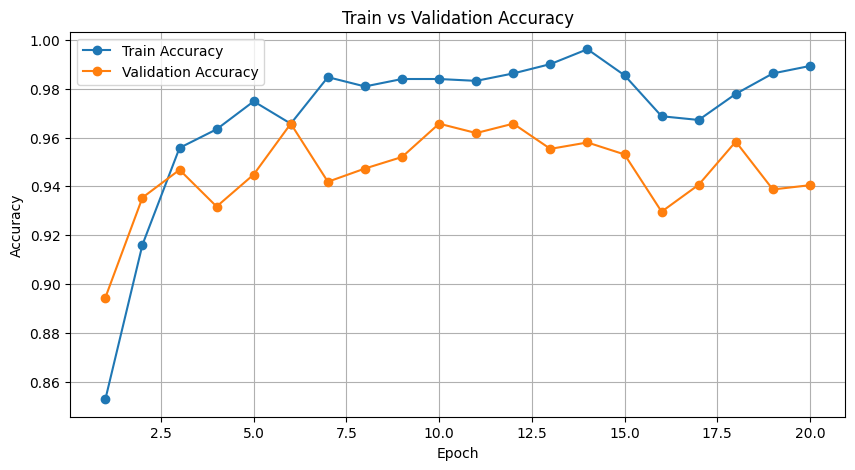

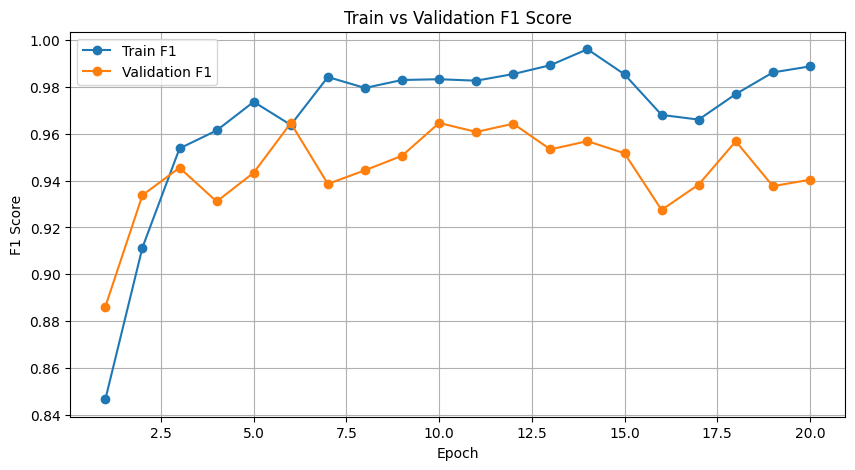

In [11]:
# ============================
# TRAIN vs VAL PLOTS
# ============================

epochs = list(range(1, len(train_accs)+1))

plt.figure(figsize=(10,5))
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, train_f1s, label="Train F1", marker='o')
plt.plot(epochs, val_f1s, label="Validation F1", marker='o')
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Score")
plt.legend()
plt.grid(True)
plt.show()


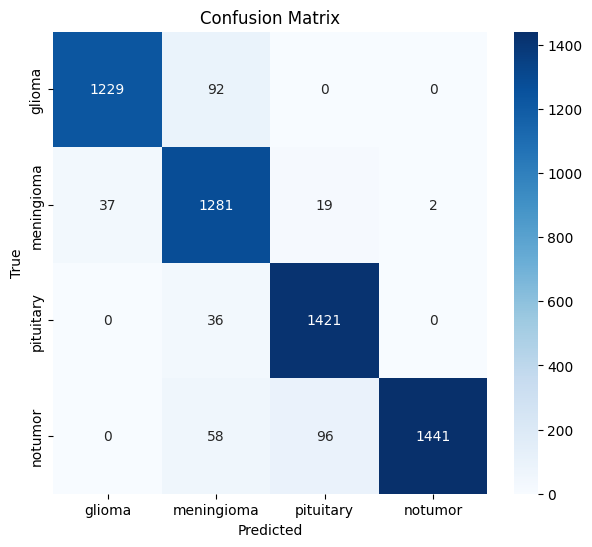

In [12]:
cm = confusion_matrix(trues, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(1)

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = self.gradients.mean(dim=(1,2), keepdim=True)
        cam = (weights * self.activations).sum(dim=0)

        cam = cam.cpu().numpy()
        cam = np.maximum(cam, 0)
        cam /= cam.max()

        return cam


In [3]:
import gradio as gr
import socket
from pyngrok import ngrok

# ============================================
# 1. YOUR PREDICT FUNCTION
# ============================================

def predict(img):
    img_tensor = test_tf(img).unsqueeze(0)
    out = (vit(img_tensor) + eff(img_tensor)) / 2
    cls_id = out.argmax(1).item()
    return classes[cls_id]

# ============================================
# 2. GRADIO INTERFACE
# ============================================

iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(label="Predicted Tumor Type"),
    title="Brain Tumor Classifier (CPU)",
    description="Upload a Brain MRI to classify into glioma / meningioma / pituitary / no tumor."
)

# ============================================
# 3. AUTO-FIND FREE PORT (IMPORTANT)
# ============================================

def get_free_port():
    s = socket.socket()
    s.bind(('', 0))
    port = s.getsockname()[1]
    s.close()
    return port

port = get_free_port()
print(f"Using free port: {port}")

# ============================================
# 4. NGROK SETUP
# ============================================

!pip install pyngrok --quiet
ngrok.set_auth_token("35ovFHG5HGyIQtoi7eBScZEo7gO_7mQnmKwSg9rFA6bbZP6BQ")   # ⭐ Put token here

# ============================================
# 5. LAUNCH GRADIO LOCALLY
# ============================================

iface.launch(
    server_port=port,
    share=True,
    inbrowser=True
)

# ============================================
# 6. CREATE NGROK PUBLIC LINK
# ============================================

public_url = ngrok.connect(port).public_url
print("\n🚀 Public Share Link:", public_url)


Using free port: 52518
* Running on local URL:  http://127.0.0.1:52518

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.



🚀 Public Share Link: https://nonqualitatively-megalithic-angelia.ngrok-free.dev


t=2025-11-25T19:29:39+0530 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=e3a6f77ebd61 err="read tcp [2606:4700:110:8b2e:f0ab:dbee:8182:44f]:60146->[2600:1f16:d83:1201:51fa:110b:1b07:ae4]:443: wsarecv: An established connection was aborted by the software in your host machine."
t=2025-11-25T19:29:39+0530 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with address \"connect.us.ngrok-agent.com:443\": dial tcp: lookup connect.us.ngrok-agent.com: no such host"
t=2025-11-25T19:29:39+0530 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with address \"connect.us.ngrok-agent.com:443\": dial tcp: lookup connect.us.ngrok-agent.com: no such host"
t=2025-11-25T19:29:40+0530 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="failed to dial ngrok server with address \"connect.us.ngrok-agent.com:443\": dial tcp: lookup connect.us.ngrok-agent.com: n